# Strawberry Disease Classification

In [1]:
import pathlib
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS   = 3
EPOCHS     = 50
# Find the Crop-Care-AI project root regardless of where the kernel's CWD is.
# The project root always contains both "training/" and "api/" subdirectories.
_cwd = pathlib.Path().resolve()
_project_root = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "training").is_dir() and (_p / "api").is_dir():
        _project_root = _p
        break
if _project_root is None:
    raise RuntimeError(f"Could not locate project root from CWD: {_cwd}")

DATA_DIR = str(_project_root.parent / "Data" / "Strawberry")
print(f"Project root : {_project_root}")
print(f"DATA_DIR     : {DATA_DIR}")

Project root : D:\Development\Shravani\Crop-Care-AI
DATA_DIR     : D:\Development\Shravani\Data\Strawberry


In [2]:
# Load pre-split datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Train", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Val", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Test", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Train batches: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

Found 3598 files belonging to 2 classes.
Found 809 files belonging to 2 classes.
Found 91 files belonging to 2 classes.
Classes: ['Healthy', 'Leaf Scorch']
Train batches: 113  |  Val: 26  |  Test: 3


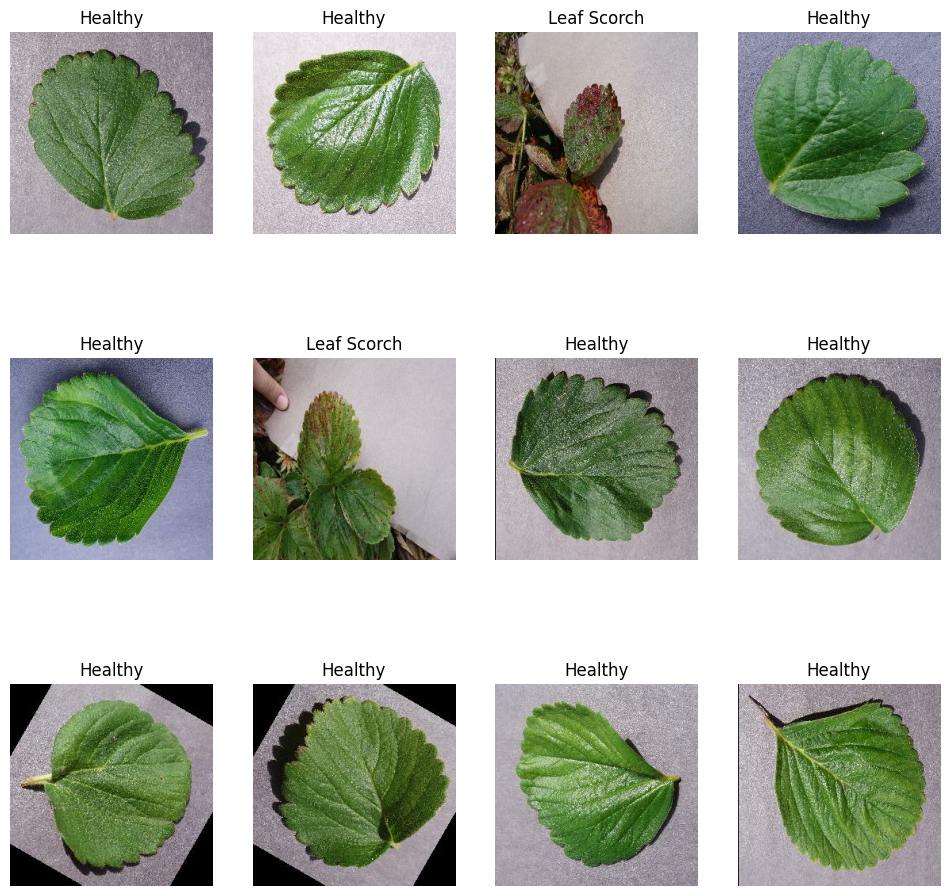

In [3]:
# Visualize sample images
plt.figure(figsize=(12, 12))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [ ]:
# Save
model.save("../strawberry.keras")
print("Saved: ../strawberry.keras")